# Fractals and fractal dimensions.

## Cantor set.
The Cantor set is a classic example of a fractal, constructed by repeatedly removing the middle third of line segments. Starting with the interval [0, 1], we remove the open middle third (1/3, 2/3), leaving two segments. This process is repeated infinitely on each remaining segment. Despite removing infinitely many points, the Cantor set is uncountable and has a fractal dimension of 
$$
log(2)/log(3) ≈ 0.631.
$$
The Cantor set demonstrates key fractal properties: self-similarity, infinite complexity at all scales, and a non-integer dimension.

In [3]:
import numpy as np
from ipywidgets import interact, IntSlider

import matplotlib.pyplot as plt

def plot_cantor(level):
    intervals = [(0.0, 1.0)]
    fig, ax = plt.subplots(figsize=(10, 1))

    for depth in range(level + 1):
        length = intervals[0][1] - intervals[0][0]
        num_intervals = len(intervals)

        if depth > 0:
            print(
                f"Depth {depth}: Length of each interval = {length:.3e}, "
                f"Number of intervals = {num_intervals:.3e}, "
                f"Dimension = {np.log(num_intervals) / np.log(1/length):.3f}"
            )

        if depth < level:
            next_intervals = []
            for left, right in intervals:
                third = (right - left) / 3
                next_intervals.extend([
                    (left, left + third),
                    (right - third, right),
                ])
            intervals = next_intervals

    print()
    print(f"Depth {depth}")
    print("Intervals =")
    for left, right in intervals:
        print(f"({left:.3e}, {right:.3e})")
        ax.plot([left, right], [0, 0], color="black")

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-level - 0.5, 0.5)
    ax.set_title(
        f"Cantor set construction (level={level})  "
        f"Length = {length:.3e}  Number of intervals = {num_intervals}"
    )
    ax.axis("off")
    plt.show()

interact(plot_cantor, level=IntSlider(value=0, min=0, max=10, step=1, description="level"));

interactive(children=(IntSlider(value=0, description='level', max=10), Output()), _dom_classes=('widget-intera…

## Koch curve
The **Koch curve** is a classic self-similar fractal built by repeatedly replacing each line segment with four shorter segments that form a triangular “bump.”  
Starting from a single segment:

1. Divide the segment into three equal parts.  
2. Replace the middle third with two sides of an equilateral triangle.  
3. Repeat this process for every segment at the next level.

With each iteration, the curve becomes more detailed and jagged. Its total length increases without bound, while the curve remains contained in a finite region. The Koch curve has fractal dimension  
$$
D=\frac{\log 4}{\log 3}\approx 1.262,
$$
which lies between a 1D line and a 2D shape.

In [4]:
# Programs 17a: Plotting the Koch curve. 
#
# See Figure 17.2.
# Made interactive with ipywidgets. You can change the value of k to see how the curve evolves as k increases.

import numpy as np
import matplotlib.pyplot as plt
from math import floor
from ipywidgets import interact, IntSlider


def plot_koch(k):
    n_lines = 4**k
    h = 3**(-k)
    x = [0] * (n_lines + 1)
    y = [0] * (n_lines + 1)
    x[0], y[0] = 0, 0
    segment = [0] * max(1, n_lines)
    angle = [0, np.pi/3, -np.pi/3, 0]

    for i in range(n_lines):
        m = i
        ang = 0
        for j in range(k):
            segment[j] = np.mod(m, 4)
            m = floor(m / 4)
            ang += angle[segment[j]]

        x[i + 1] = x[i] + h * np.cos(ang)
        y[i + 1] = y[i] + h * np.sin(ang)

    plt.figure(figsize=(8, 3))
    plt.axis('equal')
    plt.plot(x, y)
    plt.title(f'Koch curve (k={k})')
    plt.show()

interact(plot_koch, k=IntSlider(value=0, min=0, max=6, step=1, description='k'));

interactive(children=(IntSlider(value=0, description='k', max=6), Output()), _dom_classes=('widget-interact',)…

## Sierpinski triangle

The **Sierpinski triangle** is a fundamental self-similar fractal formed by recursively removing the central triangle from an equilateral triangle.

Construction idea:
1. Start with one filled equilateral triangle.  
2. Divide it into four congruent smaller triangles.  
3. Remove the central one.  
4. Repeat the process on each remaining corner triangle.

An equivalent stochastic method is the **chaos game**: repeatedly move halfway from the current point to a randomly chosen vertex of a triangle. The generated points converge to the same Sierpinski structure.



In [5]:
# Program 17b: The chaos game and Sierpinski triangle.
# See Figure 17.6.

import matplotlib.pyplot as plt
from random import random, randint
import numpy as np

def midpoint(P, Q):
    return (0.5*(P[0] + Q[0]), 0.5*(P[1] + Q[1]))

def chaos_game(iterates):
    # The three vertices.
    vertices = [(0, 0), (2, 2*np.sqrt(3)), (4, 0)]
    
    x, y = [0]*iterates, [0]*iterates
    x[0], y[0] = random(), random()
    
    for i in range(1, iterates):
        k = randint(0, 2)
        x[i], y[i] = midpoint(vertices[k], (x[i-1], y[i-1]))
    return x, y;
def chaos_game_plot(iterates):
    # The three vertices.
    
    
    x, y = chaos_game(iterates)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    ax.scatter(x, y, c=np.arange(iterates), cmap='hot', s=0.1)
    ax.axis('off')
    plt.show()
    return 

iterates_widget = IntSlider(value=1000, min=1000, max=200000, step=1000, description='iterates');
interact(chaos_game_plot, iterates=iterates_widget);
#chaos_game(10000)

interactive(children=(IntSlider(value=1000, description='iterates', max=200000, min=1000, step=1000), Output()…

## Barnsley’s Fern

**Barnsley’s fern** is a classic fractal generated by an **iterated function system (IFS)**.  
Starting from an initial point $(x_0,y_0)$ (often $(0,0)$), we repeatedly apply one of several affine maps chosen at random.

At each step:
$$
(x_{n+1},y_{n+1})=f_i(x_n,y_n),
$$
where $f_i$ is selected with probability $p_i$.

A common choice is:
- $f_1(x,y)=(0,\;0.2y)$ with $p_1=0.01$
- $f_2(x,y)=(0.85x+0.05y,\;-0.04x+0.85y+1.6)$ with $p_2=0.85$
- $f_3(x,y)=(0.2x-0.26y,\;0.23x+0.22y+1.6)$ with $p_3=0.07$
- $f_4(x,y)=(-0.15x+0.28y,\;0.26x+0.24y+0.44)$ with $p_4=0.07$

Although each map is simple, the random iteration produces a detailed fern-like structure.  
This is a key example of how stochastic linear rules can generate complex geometric patterns.

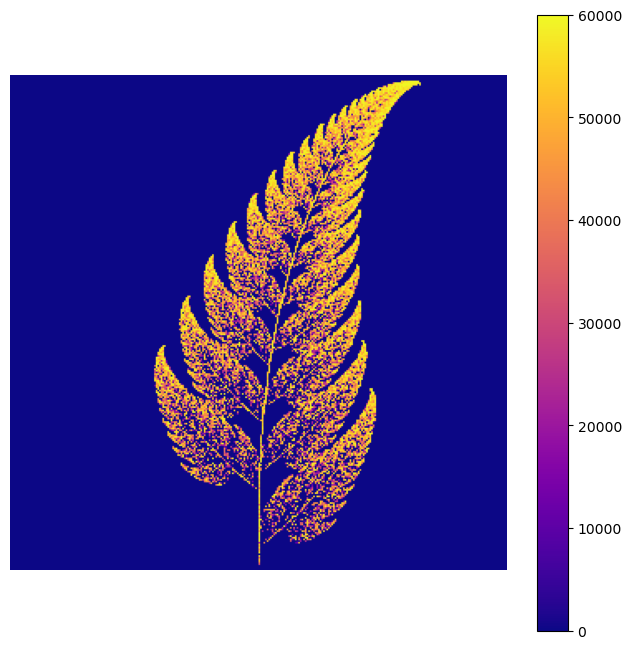

In [6]:
# Program 17c: Barnsley's fern.
# See Figure 17.7.
#import numpy as np
#import matplotlib.pyplot as plt
import matplotlib.cm as cm

# The transformation T
f1 = lambda x, y: (0.0, 0.2*y)
f2 = lambda x, y: (0.85*x + 0.05*y, -0.04*x + 0.85*y + 1.6)
f3 = lambda x, y: (0.2*x - 0.26*y, 0.23*x + 0.22*y + 1.6)
f4 = lambda x, y: (-0.15*x + 0.28*y, 0.26*x + 0.24*y + 0.44)
fs = [f1, f2, f3, f4]

p=[0.01, 0.85, 0.07, 0.07] 
num_points = 60000

width = height = 300
fern = np.zeros((width, height))

x, y = 0, 0
for i in range(num_points):
    # Choose a random transformation
    f = np.random.choice(fs, p=p)
    x, y = f(x,y)
    # Map (x,y) to pixel coordinates
    # Center the image
    cx, cy = int(width / 2 + x * width / 10), int(y * height / 10)
    fern[cy, cx] = 1+i

cmap = 'plasma' # Choose a colormap index from the list printed above, e.g., 61 for 'hot'.
fig, ax=plt.subplots(figsize=(8,8))
plt.imshow(fern[::-1,:], cmap=cmap)
plt.colorbar()
ax.axis('off')
plt.show()


# Dimensions
A **fractal dimension** is a generalization of the classical notion of dimension that captures how the complexity or "roughness" of a geometric object scales with the measurement scale.

For ordinary shapes — a line, a square, a cube — the dimension is a whole number (1, 2, 3). But many natural objects, such as coastlines, snowflakes, mountain ranges, and clouds, exhibit **self-similarity**: they look similar at every scale, and their detail never smooths out. For these objects, the effective dimension is a **non-integer** number between the usual integer dimensions.

The key idea is the **scaling relation**: if we rescale an object by a factor $r$, the number of self-similar copies $N$ satisfies
$$
N = r^D \quad \Longrightarrow \quad D = \frac{\log N}{\log r}.
$$



# Box covering 


In [10]:
def box_count_binary(binary, eps): # Count boxes of size eps x eps needed to cover the True pixels in the binary image
    h, w = binary.shape # Get image dimensions
    pad_h = (-h) % eps # Pad height to be a multiple of eps
    pad_w = (-w) % eps # Pad width to be a multiple of eps
    padded = np.pad(binary, ((0, pad_h), (0, pad_w)), mode="constant", constant_values=False) # Pad with False (empty)

    H, W = padded.shape
    blocks = padded.reshape(H // eps, eps, W // eps, eps)
    return np.any(blocks, axis=(1, 3)).sum()

Estimated box-counting dimension (Cantor): 0.669
Theoretical dimension log(2)/log(3):      0.631


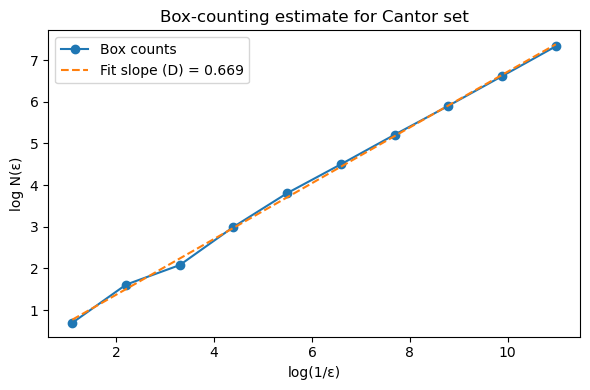

In [15]:
# Box-counting estimate for a finite-level Cantor set approximation

def cantor_intervals(level):
    intervals = [(0.0, 1.0)]
    for _ in range(level):
        nxt = []
        for a, b in intervals:
            t = (b - a) / 3.0
            nxt.append((a, a + t))
            nxt.append((b - t, b))
        intervals = nxt
    return intervals

def box_count_cantor(intervals, eps):
    hit = set()
    n = int(np.ceil(1 / eps))
    for a, b in intervals:
        i0 = max(0, int(np.floor(a / eps)))
        i1 = min(n - 1, int(np.ceil(b / eps) - 1))
        for i in range(i0, i1 + 1):
            hit.add(i)
    return len(hit)

level_cantor = 10
intervals_cantor = cantor_intervals(level_cantor)

# Use ternary scales to match Cantor geometry
k_vals = np.arange(1, level_cantor + 1)
eps_sizes_cantor = 3.0 ** (-k_vals)
counts_cantor = np.array([box_count_cantor(intervals_cantor, eps) for eps in eps_sizes_cantor])

log_inv_eps_cantor = np.log(1 / eps_sizes_cantor)
log_counts_cantor = np.log(counts_cantor)

coeffs_cantor = np.polyfit(log_inv_eps_cantor, log_counts_cantor, 1)
D_cantor = coeffs_cantor[0]
D_cantor_theory = np.log(2) / np.log(3)

print(f"Estimated box-counting dimension (Cantor): {D_cantor:.3f}")
print(f"Theoretical dimension log(2)/log(3):      {D_cantor_theory:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(log_inv_eps_cantor, log_counts_cantor, "o-", label="Box counts")
plt.plot(
    log_inv_eps_cantor,
    np.polyval(coeffs_cantor, log_inv_eps_cantor),
    "--",
    label=f"Fit slope (D) = {D_cantor:.3f}"
)
plt.xlabel("log(1/ε)")
plt.ylabel("log N(ε)")
plt.title("Box-counting estimate for Cantor set")
plt.legend()
plt.tight_layout()
plt.show()

Estimated box-counting dimension (Koch curve): 1.277
Theoretical dimension log(4)/log(3):           1.262


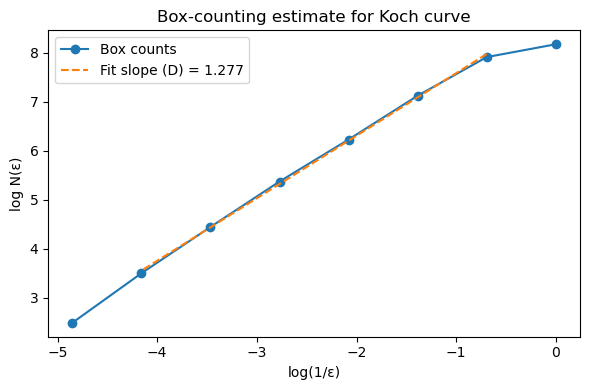

In [17]:
### The Koch curve

def koch_points(k):
    n_lines = 4**k
    h = 3**(-k)
    x = [0] * (n_lines + 1)
    y = [0] * (n_lines + 1)
    x[0], y[0] = 0, 0
    segment = [0] * max(1, n_lines)
    angle = [0, np.pi/3, -np.pi/3, 0]

    for i in range(n_lines):
        m = i
        ang = 0
        for j in range(k):
            segment[j] = np.mod(m, 4)
            m = floor(m / 4)
            ang += angle[segment[j]]
        x[i + 1] = x[i] + h * np.cos(ang)
        y[i + 1] = y[i] + h * np.sin(ang)
    return np.array(x), np.array(y)

# Generate Koch curve at level k
k_koch = 6
x_koch, y_koch = koch_points(k_koch)

# Rasterize to binary image
grid_n_koch = 512
ix_koch = ((x_koch - x_koch.min()) / (x_koch.max() - x_koch.min()) * (grid_n_koch - 1)).astype(int)
iy_koch = ((y_koch - y_koch.min()) / (y_koch.max() - y_koch.min()) * (grid_n_koch - 1)).astype(int)

binary_koch = np.zeros((grid_n_koch, grid_n_koch), dtype=bool)
binary_koch[iy_koch, ix_koch] = True

# Box-counting across scales
eps_sizes_koch = np.array([1, 2, 4, 8, 16, 32, 64, 128])
counts_koch = np.array([box_count_binary(binary_koch, eps) for eps in eps_sizes_koch])

log_inv_eps_koch = np.log(1 / eps_sizes_koch)
log_counts_koch = np.log(counts_koch)

# Fit mid-scales
fit_mask_koch = (eps_sizes_koch >= 2) & (eps_sizes_koch <= 64)
coeffs_koch = np.polyfit(log_inv_eps_koch[fit_mask_koch], log_counts_koch[fit_mask_koch], 1)
D_koch = coeffs_koch[0]
D_koch_theory = np.log(4) / np.log(3)

print(f"Estimated box-counting dimension (Koch curve): {D_koch:.3f}")
print(f"Theoretical dimension log(4)/log(3):           {D_koch_theory:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(log_inv_eps_koch, log_counts_koch, "o-", label="Box counts")
plt.plot(
    log_inv_eps_koch[fit_mask_koch],
    np.polyval(coeffs_koch, log_inv_eps_koch[fit_mask_koch]),
    "--",
    label=f"Fit slope (D) = {D_koch:.3f}"
)
plt.xlabel("log(1/ε)")
plt.ylabel("log N(ε)")
plt.title("Box-counting estimate for Koch curve")
plt.legend()
plt.tight_layout()
plt.show()

### The Sierpinski triangle


Estimated box-counting dimension (chaos game / Sierpinski): 1.572


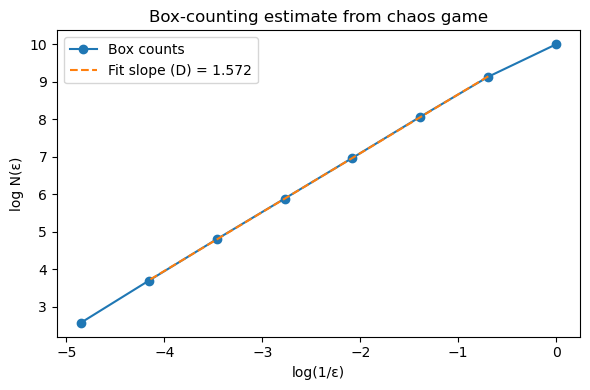

In [11]:
x,y=chaos_game(100)
# Use more points for a stable box-dimension estimate
if len(x) < 5000:
    x, y = chaos_game(50000)

# Rasterize chaos-game points to a binary image
grid_n = 512
x_arr, y_arr = np.asarray(x), np.asarray(y)

ix = ((x_arr - x_arr.min()) / (x_arr.max() - x_arr.min()) * (grid_n - 1)).astype(int)
iy = ((y_arr - y_arr.min()) / (y_arr.max() - y_arr.min()) * (grid_n - 1)).astype(int)

binary_sierpinsky = np.zeros((grid_n, grid_n), dtype=bool)
binary_sierpinsky[iy, ix] = True

# Box-counting across scales
eps_sizes_sier = np.array([1, 2, 4, 8, 16, 32, 64, 128])
counts_sier = np.array([box_count_binary(binary_sierpinsky, eps) for eps in eps_sizes_sier])

log_inv_eps_sier = np.log(1 / eps_sizes_sier)
log_counts_sier = np.log(counts_sier)

# Fit mid-scales
fit_mask_sier = (eps_sizes_sier >= 2) & (eps_sizes_sier <= 64)
coeffs_sier = np.polyfit(log_inv_eps_sier[fit_mask_sier], log_counts_sier[fit_mask_sier], 1)
D_sier = coeffs_sier[0]

print(f"Estimated box-counting dimension (chaos game / Sierpinski): {D_sier:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(log_inv_eps_sier, log_counts_sier, "o-", label="Box counts")
plt.plot(
    log_inv_eps_sier[fit_mask_sier],
    np.polyval(coeffs_sier, log_inv_eps_sier[fit_mask_sier]),
    "--",
    label=f"Fit slope (D) = {D_sier:.3f}"
)
plt.xlabel("log(1/ε)")
plt.ylabel("log N(ε)")
plt.title("Box-counting estimate from chaos game")
plt.legend()
plt.tight_layout()
plt.show()
#binary_sierpinsky = sierpinsky > 0  # occupied pixels

### Barnsley's fern

Estimated box-counting dimension of Barnsley's fern: 1.732


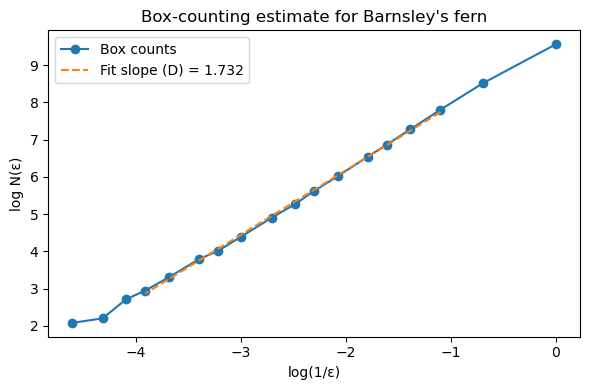

In [8]:
# Box-counting estimate of Barnsley's fern dimension from the existing `fern` image

binary_fern = fern > 0  # occupied pixels



# Box sizes in pixels (scales)
eps_sizes = np.array([1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50, 60, 75, 100])

counts_fern = np.array([box_count_binary(binary_fern, eps) for eps in eps_sizes])

# Fit on mid scales for a more stable estimate
fit_mask = (eps_sizes >= 3) & (eps_sizes <= 50)

log_inv_eps = np.log(1 / eps_sizes)
log_counts = np.log(counts_fern)

coeffs_fern = np.polyfit(log_inv_eps[fit_mask], log_counts[fit_mask], 1)
D_fern = coeffs_fern[0]

print(f"Estimated box-counting dimension of Barnsley's fern: {D_fern:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(log_inv_eps, log_counts, "o-", label="Box counts")
plt.plot(
    log_inv_eps[fit_mask],
    np.polyval(coeffs_fern, log_inv_eps[fit_mask]),
    "--",
    label=f"Fit slope (D) = {D_fern:.3f}"
)
plt.xlabel("log(1/ε)")
plt.ylabel("log N(ε)")
plt.title("Box-counting estimate for Barnsley's fern")
plt.legend()
plt.tight_layout()
plt.show()

# Coastline dimensions
To connect ideal fractals with real data, we now estimate the **box-counting dimension** of a real coastline from OpenStreetMap.

In the next cell, we:
- download coastline geometries for a chosen region (`place`),
- project coordinates to a metric CRS (`epsg_code`) so box sizes are in meters,
- count how many grid boxes of size $\varepsilon$ intersect the coastline,
- fit a line to the log–log relation
    $$
    \log N(\varepsilon) \approx D\,\log(1/\varepsilon) + c
    $$
    and use its slope as the dimension estimate.

For the current dataset (**Bergen, Norway**), the estimated coastline dimension is
$$
D \approx 1.263,
$$
which is between 1 (smooth curve) and 2 (area-filling set), reflecting geometric roughness across scales.

In [13]:
!pip install osmnx geopandas

def utm_epsg_from_latlon(lat, lon):
    zone = int((lon + 180) // 6) + 1
    if lat >= 0:
        return 32600 + zone
    else:
        return 32700 + zone


Number of coastline segments: 812
UTM EPSG code for Bergen, Norway: 32631
Total coastline length: 320.95 km


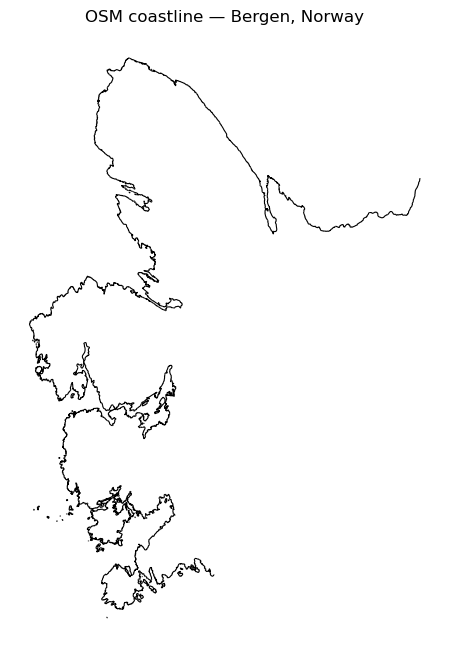

Estimated box-counting dimension: 1.263


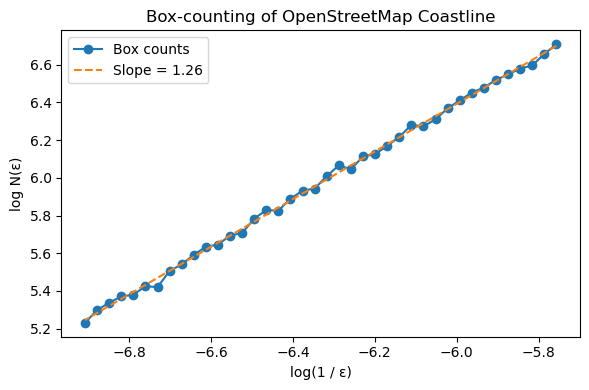

In [14]:

# ================================
# Box-counting dimension of OSM coastline
# ================================

# ---- imports ----
import osmnx as ox
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box

# ---- 1. Download coastline from OpenStreetMap ----
place = "Vestland, Norway"   # change region if desired

place = "Bergen, Norway"
#place="Galway, Ireland"
tags = {"natural": "coastline"}

coast = ox.features_from_place(place, tags)
coast = coast[coast.geometry.type.isin(["LineString", "MultiLineString"])]
minx, miny, maxx, maxy=coast.total_bounds
lon=0.5*(minx+maxx)
lat=0.5*(miny+maxy)

print(f"Number of coastline segments: {len(coast)}")
# ---- 2. Project to metric coordinates (meters) ----
epsg_code=utm_epsg_from_latlon(lat, lon)
print(f"UTM EPSG code for {place}: {epsg_code}")
coast = coast.to_crs(epsg=epsg_code)# 32633)  # UTM zone 33N (western Norway)
#coast = coast.to_crs(epsg=32629)  # UTM zone 29N (western Ireland)
geometry = coast.geometry
print(f"Total coastline length: {geometry.length.sum()/1000:.2f} km")
# ---- 3. Box-counting function ----
def box_count(geometry, eps):
    xmin, ymin, xmax, ymax = geometry.total_bounds

    nx = int(np.ceil((xmax - xmin) / eps))
    ny = int(np.ceil((ymax - ymin) / eps))

    count = 0
    for i in range(nx):
        for j in range(ny):
            cell = box(
                xmin + i * eps,
                ymin + j * eps,
                xmin + (i + 1) * eps,
                ymin + (j + 1) * eps
            )
            if geometry.intersects(cell).any():
                count += 1
    return count

    # Optional quick map of the extracted coastline
fig, ax = plt.subplots(figsize=(8, 8))

coast.plot(ax=ax, color="black", linewidth=0.8)
ax.set_title(f"OSM coastline — {place}")
ax.set_aspect("equal")
ax.axis("off")
plt.show()
# ---- 4. Choose box sizes (scales) ----
epsilons = np.logspace(2.5, 3, 40)  # ~300 m to 100 km
counts = np.array([box_count(geometry, eps) for eps in epsilons])

# ---- 5. Estimate box-counting dimension ----
log_eps = np.log(1 / epsilons)
log_N = np.log(counts)

coeffs = np.polyfit(log_eps, log_N, 1)
D = coeffs[0]

print(f"Estimated box-counting dimension: {D:.3f}")

# ---- 6. Diagnostic log-log plot ----
plt.figure(figsize=(6,4))
plt.plot(log_eps, log_N, "o-", label="Box counts")
plt.plot(log_eps, np.polyval(coeffs, log_eps), "--", label=f"Slope = {D:.2f}")
plt.xlabel("log(1 / ε)")
plt.ylabel("log N(ε)")
plt.legend()
plt.title("Box-counting of OpenStreetMap Coastline")
plt.tight_layout()
plt.show()